# Comparing Normalization Methods with Pipelines

Trong notebook này, chúng ta sẽ sử dụng `Pipeline` để triển khai và so sánh hiệu quả của các phương pháp chuẩn hóa dữ liệu:
- Không chuẩn hóa (No Scaling).
- Min-Max Scaling.
- Standardization.

Các bước chính:
- Tạo Pipelines cho từng phương pháp.
- Áp dụng các mô hình Random Forest và XGBoost.
- So sánh hiệu suất dựa trên Mean Squared Error (MSE) và R-squared (R²).


In [1]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score


## Load và chuẩn bị dữ liệu

In [2]:
# Đọc dữ liệu
train_df = pd.read_csv('data/train.csv')
features_df = pd.read_csv('data/features.csv')

# Gộp dữ liệu dựa trên Store và Date
merged_df = pd.merge(train_df, features_df, on=['Store', 'Date'], how='inner')

# Mã hóa cột phân loại (Dept và IsHoliday)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
merged_df['Dept'] = label_encoder.fit_transform(merged_df['Dept'])
merged_df['IsHoliday'] = merged_df['IsHoliday_x'].astype(int)

# Điền giá trị NaN bằng 0 cho các cột MarkDown
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
merged_df[markdown_cols] = merged_df[markdown_cols].fillna(0)

# Loại bỏ các ngoại lệ bằng IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

columns_to_check = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
for col in columns_to_check:
    merged_df = remove_outliers(merged_df, col)

# Tách đặc trưng và biến mục tiêu
features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Dept', 'IsHoliday'] + markdown_cols
X = merged_df[features]
y = merged_df['Weekly_Sales']

# Chia tập dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Tạo Pipelines và So sánh

In [3]:
# Tạo danh sách các scaler
scalers = {
    "No Scaling": None,
    "Min-Max Scaling": MinMaxScaler(),
    "Standardization": StandardScaler()
}

# Tạo danh sách các mô hình
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1)
}

# Kết quả
results = []

# Lặp qua từng scaler và mô hình
for scaling_name, scaler in scalers.items():
    for model_name, model in models.items():
        if scaler is not None:
            pipeline = Pipeline([
                ("scaler", scaler),
                ("model", model)
            ])
        else:
            pipeline = Pipeline([
                ("model", model)
            ])
        
        # Huấn luyện pipeline
        pipeline.fit(X_train, y_train)
        
        # Dự đoán
        y_pred = pipeline.predict(X_test)
        
        # Tính toán MSE và R²
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        results.append((scaling_name, model_name, mse, r2))

## Trực quan hóa kết quả

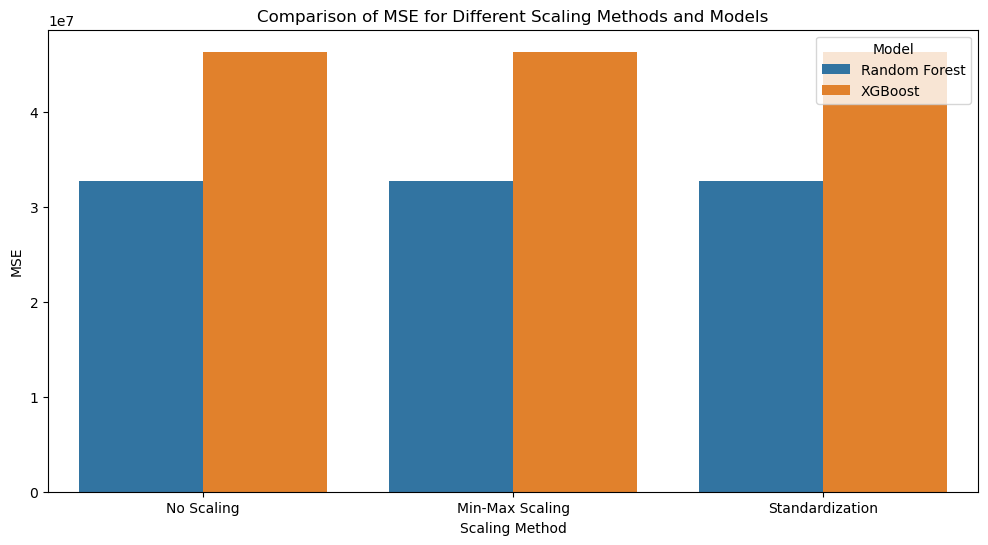

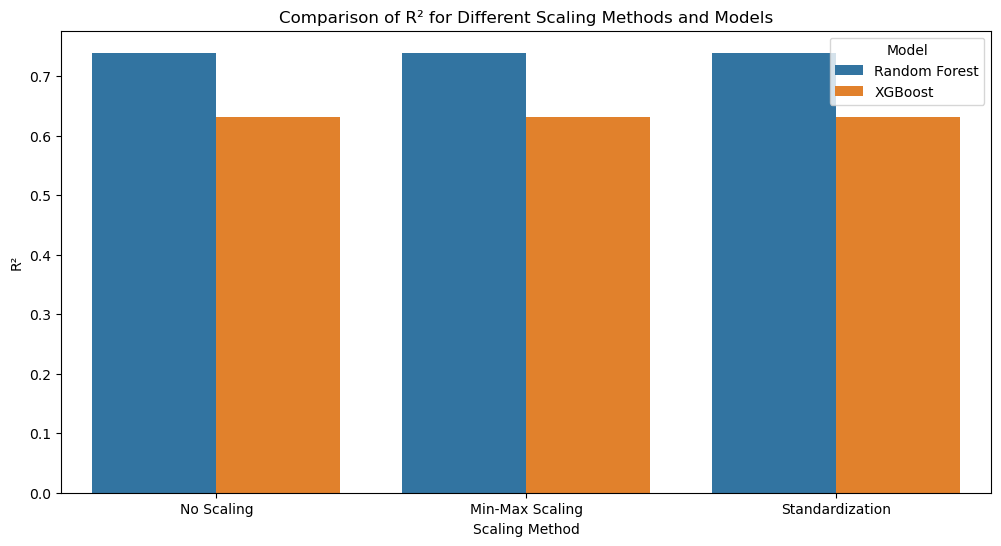

In [4]:
# Chuyển kết quả thành DataFrame
results_df = pd.DataFrame(results, columns=["Scaling Method", "Model", "MSE", "R²"])

# Biểu đồ cột so sánh MSE
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Scaling Method", y="MSE", hue="Model")
plt.title("Comparison of MSE for Different Scaling Methods and Models")
plt.show()

# Biểu đồ cột so sánh R²
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Scaling Method", y="R²", hue="Model")
plt.title("Comparison of R² for Different Scaling Methods and Models")
plt.show()

## Kết luận
- **Random Forest:** Không quá nhạy với các phương pháp chuẩn hóa.
- **XGBoost:** Với dữ liệu này, kết quả chuẩn hóa và không chuẩn hóa tương đối giống nhau.
- **Đề xuất:** Bạn có thể bỏ qua chuẩn hóa nếu cần tối ưu tốc độ cho Random Forest.